# Keras TF 2.0 - Code Along Classification Project

Let's explore a classification task with Keras API for TF 2.0

## The Data

### Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        - class:
                - WDBC-Malignant
                - WDBC-Benign

    :Summary Statistics:

    ===================================== ====== ======
                                           Min    Max
    ===================================== ====== ======
    radius (mean):                        6.981  28.11
    texture (mean):                       9.71   39.28
    perimeter (mean):                     43.79  188.5
    area (mean):                          143.5  2501.0
    smoothness (mean):                    0.053  0.163
    compactness (mean):                   0.019  0.345
    concavity (mean):                     0.0    0.427
    concave points (mean):                0.0    0.201
    symmetry (mean):                      0.106  0.304
    fractal dimension (mean):             0.05   0.097
    radius (standard error):              0.112  2.873
    texture (standard error):             0.36   4.885
    perimeter (standard error):           0.757  21.98
    area (standard error):                6.802  542.2
    smoothness (standard error):          0.002  0.031
    compactness (standard error):         0.002  0.135
    concavity (standard error):           0.0    0.396
    concave points (standard error):      0.0    0.053
    symmetry (standard error):            0.008  0.079
    fractal dimension (standard error):   0.001  0.03
    radius (worst):                       7.93   36.04
    texture (worst):                      12.02  49.54
    perimeter (worst):                    50.41  251.2
    area (worst):                         185.2  4254.0
    smoothness (worst):                   0.071  0.223
    compactness (worst):                  0.027  1.058
    concavity (worst):                    0.0    1.252
    concave points (worst):               0.0    0.291
    symmetry (worst):                     0.156  0.664
    fractal dimension (worst):            0.055  0.208
    ===================================== ====== ======

    :Missing Attribute Values: None

    :Class Distribution: 212 - Malignant, 357 - Benign

    :Creator:  Dr. William H. Wolberg, W. Nick Street, Olvi L. Mangasarian

    :Donor: Nick Street

    :Date: November, 1995

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df["benign_0__mal_1"] = cancer.target

In [6]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## EDA

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

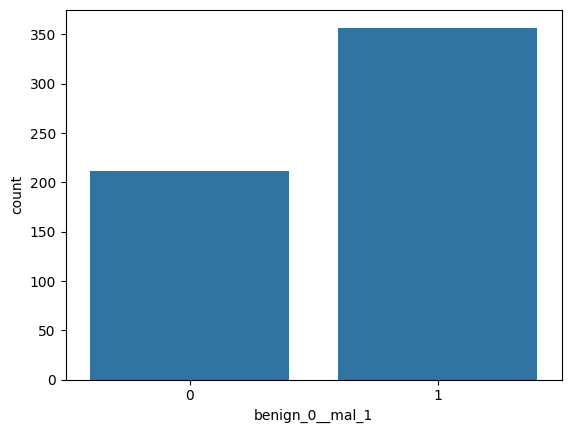

In [10]:
sns.countplot(x="benign_0__mal_1", data=df)
plt.show()

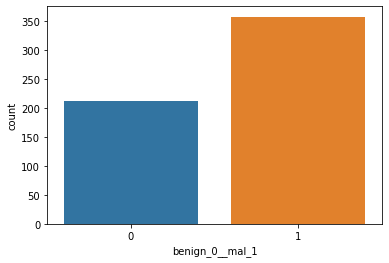

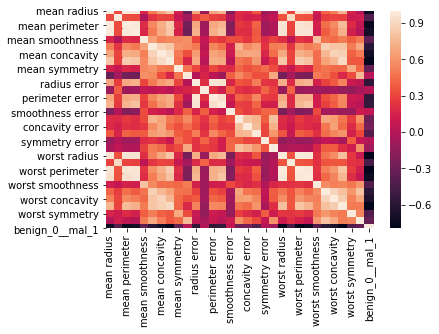

In [19]:
# Based on 'benign_0__mal_1'
X = df.drop("benign_0__mal_1", axis=1)
y = df["benign_0__mal_1"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Scaling Data

In [22]:
model = Sequential()

model.add(Dense(30, activation="relu"))
model.add(Dense(15, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [23]:
model.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test)
)

Epoch 1/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3744 - loss: 0.6913 - val_accuracy: 0.3977 - val_loss: 0.6736
Epoch 2/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5276 - loss: 0.6596 - val_accuracy: 0.6725 - val_loss: 0.6367
Epoch 3/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6910 - loss: 0.6251 - val_accuracy: 0.7310 - val_loss: 0.5991
Epoch 4/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7714 - loss: 0.5896 - val_accuracy: 0.8304 - val_loss: 0.5591
Epoch 5/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8467 - loss: 0.5525 - val_accuracy: 0.8480 - val_loss: 0.5168
Epoch 6/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8618 - loss: 0.5123 - val_accuracy: 0.8830 - val_loss: 0.4737
Epoch 7/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8693 - loss: 0.4722 - val_accuracy: 0.8830 - val_loss: 0.4316
Epoch 8/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8769 - loss: 0.4326 - val_accuracy: 0.

In [24]:
# model.history.history
model.history.history

{'accuracy': [0.37437185645103455,
  0.5276381969451904,
  0.6909547448158264,
  0.7713567614555359,
  0.8467336893081665,
  0.8618090748786926,
  0.8693467378616333,
  0.876884400844574,
  0.876884400844574,
  0.8844221234321594,
  0.8919597864151001,
  0.8869346976280212,
  0.9045225977897644,
  0.909547746181488,
  0.9170854091644287,
  0.909547746181488,
  0.9195979833602905,
  0.9221105575561523,
  0.929648220539093,
  0.9221105575561523,
  0.9371859431266785,
  0.9346733689308167,
  0.9371859431266785,
  0.947236180305481,
  0.9422110319137573,
  0.9597989916801453,
  0.9597989916801453,
  0.9547738432884216,
  0.9572864174842834,
  0.9597989916801453,
  0.9572864174842834,
  0.9623115658760071,
  0.9698492288589478,
  0.9698492288589478,
  0.9723618030548096,
  0.9748743772506714,
  0.9723618030548096,
  0.9723618030548096,
  0.9673366546630859,
  0.9748743772506714,
  0.9748743772506714,
  0.9773869514465332,
  0.9723618030548096,
  0.9748743772506714,
  0.9773869514465332,
  0

In [25]:
# model_loss
model_loss = pd.DataFrame(model.history.history)
model_loss.head()

,accuracy,loss,val_accuracy,val_loss
0,0.374372,0.691348,0.397661,0.673645
1,0.527638,0.659599,0.672515,0.636724
2,0.690955,0.625093,0.730994,0.599100
3,0.771357,0.589604,0.830409,0.559109
4,0.846734,0.552530,0.847953,0.516755


<Axes: >

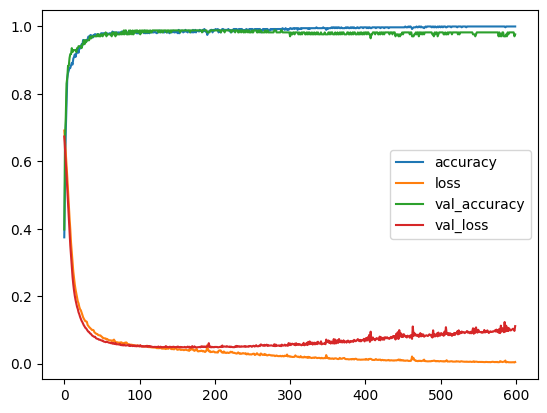

In [26]:
model_loss.plot()

## Example Two: Early Stopping

We obviously trained too much! Let's use early stopping to track the val_loss and stop training once it begins increasing too much!

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

Stop training when a monitored quantity has stopped improving.

    Arguments:
        monitor: Quantity to be monitored.
        min_delta: Minimum change in the monitored quantity
            to qualify as an improvement, i.e. an absolute
            change of less than min_delta, will count as no
            improvement.
        patience: Number of epochs with no improvement
            after which training will be stopped.
        verbose: verbosity mode.
        mode: One of `{"auto", "min", "max"}`. In `min` mode,
            training will stop when the quantity
            monitored has stopped decreasing; in `max`
            mode it will stop when the quantity
            monitored has stopped increasing; in `auto`
            mode, the direction is automatically inferred
            from the name of the monitored quantity.

In [28]:
early_stop = EarlyStopping(
    monitor="val_loss",
    mode="min",
    verbose=1,
    patience=25
)

In [29]:
model = Sequential()

model.add(Dense(30, activation="relu"))
model.add(Dense(15, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6281 - loss: 0.7010 - val_accuracy: 0.6667 - val_loss: 0.6687
Epoch 2/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7864 - loss: 0.6472 - val_accuracy: 0.8655 - val_loss: 0.6191
Epoch 3/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8543 - loss: 0.6024 - val_accuracy: 0.8655 - val_loss: 0.5695
Epoch 4/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8794 - loss: 0.5567 - val_accuracy: 0.8889 - val_loss: 0.5192
Epoch 5/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8970 - loss: 0.5078 - val_accuracy: 0.8947 - val_loss: 0.4626
Epoch 6/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8869 - loss: 0.4536 - val_accuracy: 0.9064 - val_loss: 0.4069
Epoch 7/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8894 - loss: 0.4044 - val_accuracy: 0.9123 - val_loss: 0.3602
Epoch 8/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8945 - loss: 0.3621 - val_accuracy: 0.

## Example Three: Adding in DropOut Layers

In [32]:
from tensorflow.keras.layers import Dropout

In [33]:
model = Sequential()

model.add(Dense(30, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(15, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [34]:
model.fit(
    x=X_train,
    y=y_train,
    epochs=600,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5452 - loss: 0.7439 - val_accuracy: 0.6199 - val_loss: 0.7193
Epoch 2/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5804 - loss: 0.7217 - val_accuracy: 0.6257 - val_loss: 0.6969
Epoch 3/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5477 - loss: 0.7027 - val_accuracy: 0.6316 - val_loss: 0.6835
Epoch 4/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5854 - loss: 0.6845 - val_accuracy: 0.6316 - val_loss: 0.6719
Epoch 5/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6332 - loss: 0.6716 - val_accuracy: 0.6316 - val_loss: 0.6618
Epoch 6/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6482 - loss: 0.6682 - val_accuracy: 0.6667 - val_loss: 0.6479
Epoch 7/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6658 - loss: 0.6518 - val_accuracy: 0.7368 - val_loss: 0.6298
Epoch 8/600
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7136 - loss: 0.6415 - val_accuracy: 0.

# Model Evaluation

In [35]:
from sklearn.metrics import classification_report,confusion_matrix

In [36]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [37]:
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[ 55   8]
 [  4 104]]
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        63
           1       0.93      0.96      0.95       108

    accuracy                           0.93       171
   macro avg       0.93      0.92      0.92       171
weighted avg       0.93      0.93      0.93       171



In [38]:
import joblib

In [39]:
joblib.dump(model, "model_weights.pkl")

['model_weights.pkl']

In [40]:
joblib.dump(scaler, "scaler_weights.pkl")

['scaler_weights.pkl']